In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# needed this to make it run on my computer, can be safely ignored
# import sys
# sys.path.append('D:\\Projects\\QAP_Assignment\\src')
# print(sys.path)

['D:\\Projects\\QAP_Assignment\\notebooks', 'C:\\ProgramData\\anaconda3\\python311.zip', 'C:\\ProgramData\\anaconda3\\DLLs', 'C:\\ProgramData\\anaconda3\\Lib', 'C:\\ProgramData\\anaconda3', '', 'C:\\Users\\Vincent\\AppData\\Roaming\\Python\\Python311\\site-packages', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages\\win32', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages\\win32\\lib', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages\\Pythonwin', 'D:\\Projects\\QAP_Assignment\\src']


In [3]:
import time

import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.operators.crossover.ox import OrderCrossover
from pymoo.operators.mutation.inversion import InversionMutation
from pymoo.operators.sampling.rnd import PermutationRandomSampling
from pymoo.optimize import minimize
from pymoo.termination import get_termination
from pymoo.termination.collection import TerminationCollection
from pymoo.termination.default import DefaultSingleObjectiveTermination
from tqdm import tqdm

from qap_assignment.dataset import make_dataset, parse_dat_file
from qap_assignment.operators import SwapMutation, TabuSearchRepair
from qap_assignment.problem import QAP

make_dataset()

In [4]:
def run_kra(seed):
    n, A, B = parse_dat_file("kra30a")
    problem = QAP(n, A, B)

    algorithm = GA(
        pop_size=50,
        sampling=PermutationRandomSampling(),
        # `Crossover` uses prob=0.9 by default anyway
        crossover=OrderCrossover(prob=0.9),
        mutation=SwapMutation(prob=0.2),
        # By default, tournament selection and elitist survival is used
        repair=TabuSearchRepair(),
    )

    termination = TerminationCollection(
        DefaultSingleObjectiveTermination(
            period=30,  # Don't think this matters much since we have local search
            n_max_gen=50000,
            # Make n_max_evals really big since I don't care about this
            n_max_evals=2**64,
        ),
        # Why is fmin not documented...
        # Shouldn't hardcode this, kra30a has a known optimum
        get_termination("fmin", 88900),
    )

    start_time = time.perf_counter()
    res = minimize(problem, algorithm, termination, seed=seed, verbose=True)
    end_time = time.perf_counter()
    return {
        "cost": res.F[0],
        "time": end_time - start_time,
    }

In [5]:
seed_sequence = np.random.SeedSequence(42)
run_seeds = seed_sequence.generate_state(50)
tasks = (delayed(run_kra)(seed) for seed in run_seeds)
kra_results = []
for res in tqdm(
    Parallel(n_jobs=8, return_as="generator_unordered")(tasks),
    total=50,
):
    kra_results.append(res)

100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:05<00:00,  8.78it/s]


In [6]:
avg_kra_cost = np.average([r["cost"] for r in kra_results])
avg_kra_time = np.average([r["time"] for r in kra_results])
print(avg_kra_cost)
print(avg_kra_time)
print(np.min([r["cost"] for r in kra_results]))

88900.0
0.5292842079998809
88900.0


In [7]:
def run_tai(seed):
    n, A, B = parse_dat_file("tai40a")
    problem = QAP(n, A, B)

    algorithm = GA(
        pop_size=100,
        sampling=PermutationRandomSampling(),
        # `Crossover` uses prob=0.9 by default anyway
        crossover=OrderCrossover(prob=0.95),
        mutation=SwapMutation(
            prob=0.4
        ),  # 0.4 swap prob, 0.95 crossover is the best i've gotten so far
        # By default, tournament selection and elitist survival is used
        repair=TabuSearchRepair(),
    )

    termination = TerminationCollection(
        DefaultSingleObjectiveTermination(
            period=30,  # Don't think this matters much since we have local search
            n_max_gen=50000,
            # Make n_max_evals really big since I don't care about this
            n_max_evals=2**64,
        ),
    )

    start_time = time.perf_counter()
    res = minimize(problem, algorithm, termination, seed=seed, verbose=True)
    end_time = time.perf_counter()
    return {
        "cost": res.F[0],
        "time": end_time - start_time,
    }

In [8]:
seed_sequence = np.random.SeedSequence(42)
run_seeds = seed_sequence.generate_state(50)
tasks = (delayed(run_tai)(seed) for seed in run_seeds)
tai_results = []
for res in tqdm(
    Parallel(n_jobs=8, return_as="generator_unordered")(tasks),
    total=50,
):
    tai_results.append(res)

100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [01:06<00:00,  1.34s/it]


In [9]:
avg_tai_cost = np.average([r["cost"] for r in tai_results])
avg_tai_time = np.average([r["time"] for r in tai_results])
print(avg_tai_cost)
print(avg_tai_time)
print(np.min([r["cost"] for r in tai_results]))

3153351.0
10.11432633600023
3141702.0


In [17]:
kra_cost_std = np.std([r["cost"] for r in kra_results])
kra_time_std = np.std([r["time"] for r in kra_results])
min_kra_cost = np.min([r["cost"] for r in kra_results])
max_kra_cost = np.max([r["cost"] for r in kra_results])
min_kra_time = np.min([r["time"] for r in kra_results])
max_kra_time = np.max([r["time"] for r in kra_results])

tai_cost_std = np.std([r["cost"] for r in tai_results])
tai_time_std = np.std([r["time"] for r in tai_results])
min_tai_cost = np.min([r["cost"] for r in tai_results])
max_tai_cost = np.max([r["cost"] for r in tai_results])
min_tai_time = np.min([r["time"] for r in tai_results])
max_tai_time = np.max([r["time"] for r in tai_results])


In [18]:
print('Average KRA cost: ' + str(avg_kra_cost))
print('Average KRA time: ' + str(avg_kra_time))
print('KRA cost Std. Dev.: ' + str(kra_cost_std))
print('KRA time Std. Dev.: ' + str(kra_time_std))
print('Min KRA cost: ' + str(min_kra_cost))
print('Max KRA cost: ' + str(max_kra_cost))
print('Min KRA time: ' + str(min_kra_time))
print('Max KRA time: ' + str(max_kra_time))

Average KRA cost: 88900.0
Average KRA time: 0.5292842079998809
KRA cost Std. Dev.: 0.0
KRA time Std. Dev.: 0.62281334739521
Min KRA cost: 88900.0
Max KRA cost: 88900.0
Min KRA time: 0.029906699999628472
Max KRA time: 1.9460613999999623


In [19]:
print('Average TAI cost: ' + str(avg_tai_cost))
print('Average TAI time: ' + str(avg_tai_time))
print('TAI cost Std. Dev.: ' + str(tai_cost_std))
print('TAI time Std. Dev.: ' + str(tai_time_std))
print('Min TAI cost: ' + str(min_tai_cost))
print('Max TAI cost: ' + str(max_tai_cost))
print('Min TAI time: ' + str(min_tai_time))
print('Max TAI time: ' + str(max_tai_time))

Average TAI cost: 3153351.0
Average TAI time: 10.11432633600023
TAI cost Std. Dev.: 4093.6441125237056
TAI time Std. Dev.: 2.5840267590602544
Min TAI cost: 3141702.0
Max TAI cost: 3163386.0
Min TAI time: 6.331650399999489
Max TAI time: 18.50786970000081


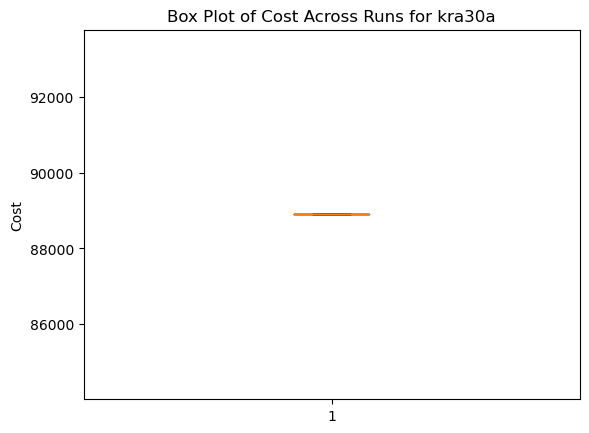

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot([r["cost"] for r in kra_results])
plt.ylabel("Cost")
plt.title("Box Plot of Cost Across Runs for kra30a")
plt.show()

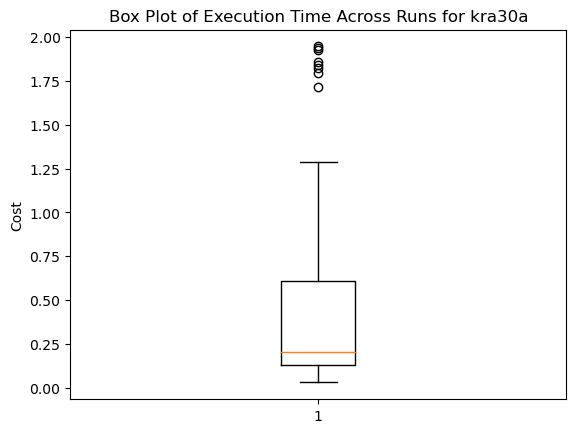

In [14]:
plt.figure()
plt.boxplot([r["time"] for r in kra_results])
plt.ylabel("Cost")
plt.title("Box Plot of Execution Time Across Runs for kra30a")
plt.show()

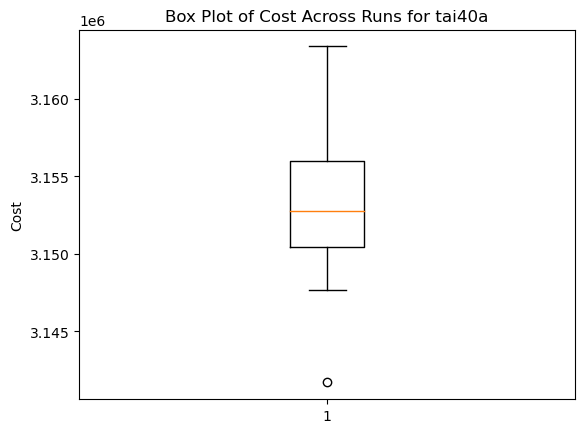

In [15]:
plt.figure()
plt.boxplot([r["cost"] for r in tai_results])
plt.ylabel("Cost")
plt.title("Box Plot of Cost Across Runs for tai40a")
plt.show()

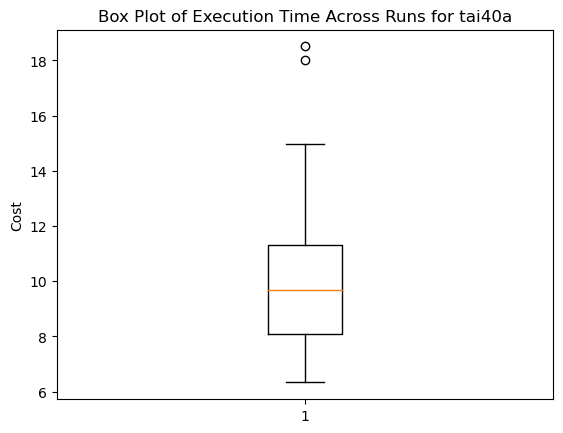

In [16]:
plt.figure()
plt.boxplot([r["time"] for r in tai_results])
plt.ylabel("Cost")
plt.title("Box Plot of Execution Time Across Runs for tai40a")
plt.show()